Original Raw Shape: torch.Size([56, 500, 1])
Broken Permute Shape (C, F, T): torch.Size([1, 500, 56])
Fixed Permute Shape (C, T, F): torch.Size([1, 56, 500])


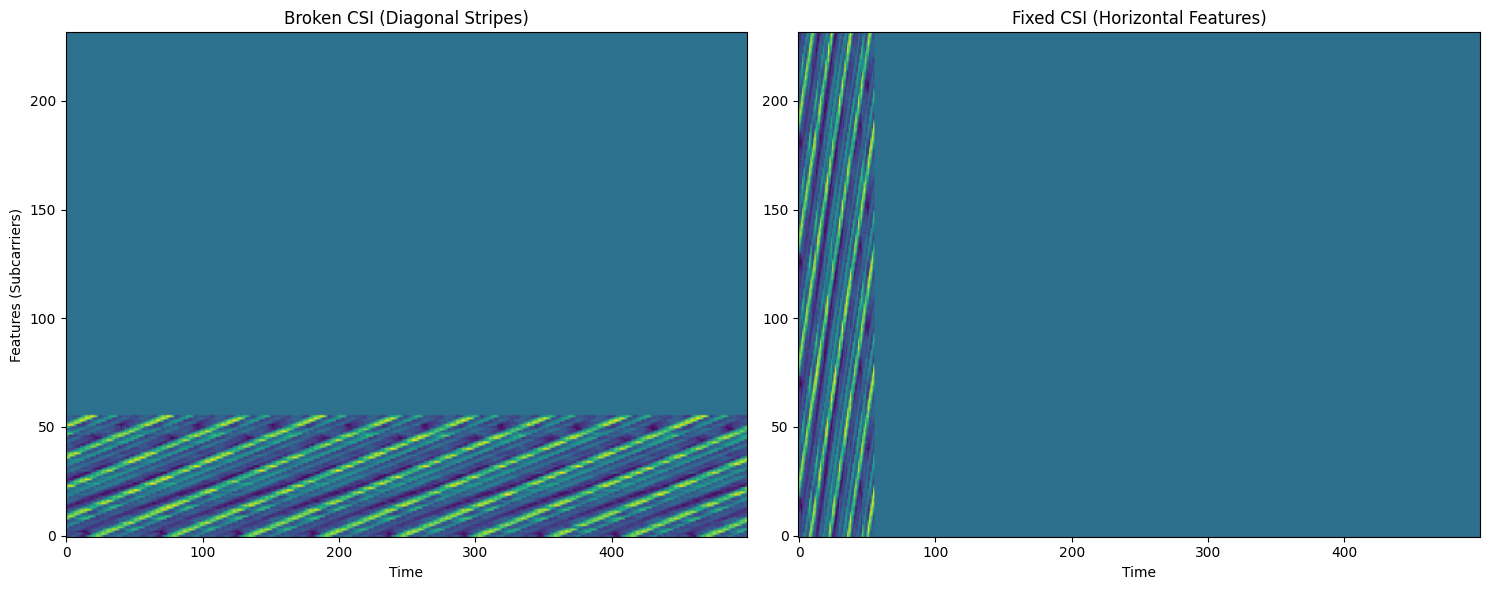

In [3]:
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

# Grab a random file from your dataset
test_file = "data/HumanActivityRecognition/sub_Human/user_U01/act_jumping/env_E01/device_AmazonPlug/session_1000__freq56_2G.h5" # Update this path!

# 1. Load Raw Data
with h5py.File(test_file, "r") as f:
    csi_data = np.array(f['CSI_amps'])
    
csi_tensor = torch.from_numpy(csi_data).float()
print(f"Original Raw Shape: {csi_tensor.shape}")

# 2. Simulate the Broken Permute
broken_tensor = csi_tensor.permute(2, 1, 0)
print(f"Broken Permute Shape (C, F, T): {broken_tensor.shape}")

# 3. Simulate the Fixed Permute
fixed_tensor = csi_tensor.permute(2, 0, 1)
print(f"Fixed Permute Shape (C, T, F): {fixed_tensor.shape}")

# 4. Standardize and Pad (Using your exact logic)
def pad_and_clip(tensor):
    mean = tensor.mean(dim=(1, 2), keepdim=True)
    std = tensor.std(dim=(1, 2), keepdim=True)
    tensor = (tensor - mean) / torch.clamp(std, min=1e-8)
    
    batch_size, dim1, dim2 = tensor.shape
    padded = torch.zeros((batch_size, 500, 232))
    c_dim1 = min(dim1, 500)
    c_dim2 = min(dim2, 232)
    padded[:, :c_dim1, :c_dim2] = tensor[:, :c_dim1, :c_dim2]
    return padded.squeeze(0)

broken_padded = pad_and_clip(broken_tensor)
fixed_padded = pad_and_clip(fixed_tensor)

# 5. Plot Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot Broken
im1 = ax1.imshow(broken_padded.numpy().T, aspect='auto', origin='lower', cmap='viridis')
ax1.set_title("Broken CSI (Diagonal Stripes)")
ax1.set_ylabel("Features (Subcarriers)")
ax1.set_xlabel("Time")

# Plot Fixed
im2 = ax2.imshow(fixed_padded.numpy().T, aspect='auto', origin='lower', cmap='viridis')
ax2.set_title("Fixed CSI (Horizontal Features)")
ax2.set_xlabel("Time")

plt.tight_layout()
plt.show()

In [4]:
with h5py.File(test_file, "r") as f:
    csi_data = np.array(f['CSI_amps'])

print(csi_data.shape)
# Should print something like (47, 52, 3)
#                               T    F   C
# NOT (3, 52, 47) or similar

(56, 500, 1)


Using provided task directory: data/BreathingDetection
Using split: train_id
Loaded 69996 samples for BreathingDetection - train_id
Using provided task directory data/BreathingDetection
Using provided task directory: data/BreathingDetection
Using split: train_id
Loaded 69996 samples for BreathingDetection - train_id
Loaded 69996 samples for BreathingDetection - train_id
Using provided task directory data/BreathingDetection
Using provided task directory: data/BreathingDetection
Using split: val_id
Loaded 14997 samples for BreathingDetection - val_id
Loaded 14997 samples for BreathingDetection - val_id
Using provided task directory data/BreathingDetection
Using provided task directory: data/BreathingDetection
Using split: test_easy_id
Loaded 5666 samples for BreathingDetection - test_easy_id
Loaded 5666 samples for BreathingDetection - test_easy_id
Using provided task directory data/BreathingDetection
Using provided task directory: data/BreathingDetection
Using split: test_medium_id
Load

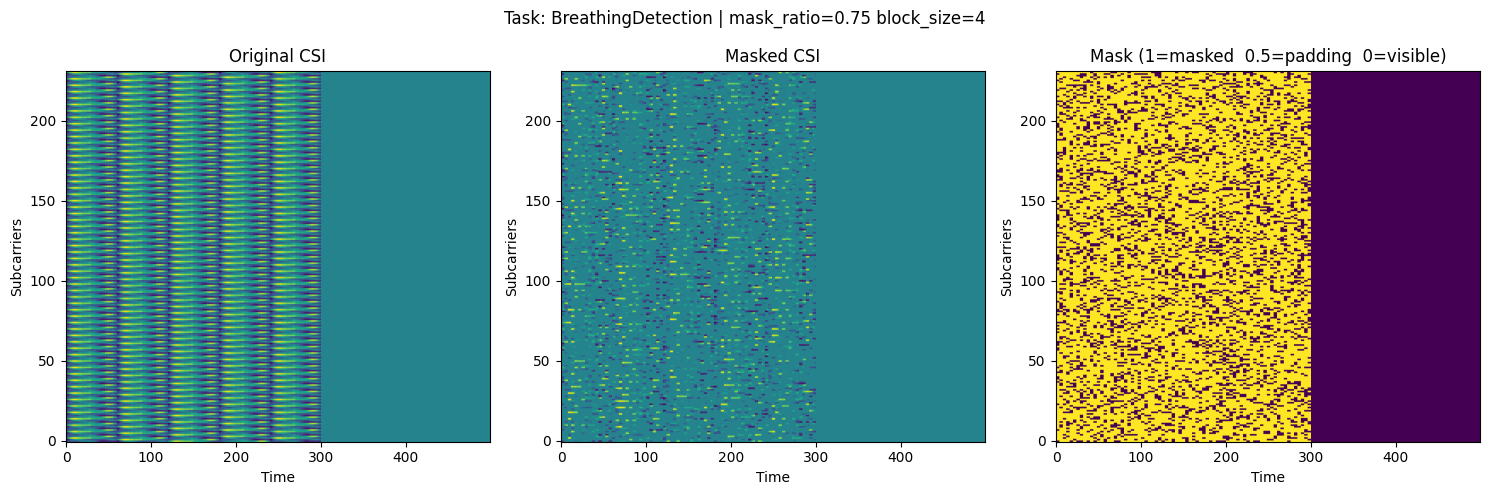

In [14]:
#!/usr/bin/env python3
import sys
import torch
import matplotlib.pyplot as plt

sys.path.append(".")  # run from project root

from load.pretrain_dataset import PretrainDataset
from torch.utils.data import DataLoader
from engine.masked_trainer import compute_padding_mask, create_padding_aware_mask
from load.dataloader import get_loaders

# --- Config ---
TASK     = "BreathingDetection"   # swap to any task you want to visualize
DATA_DIR = "data"
MASK_RATIO = 0.75
BLOCK_SIZE = 4

# --- Load one batch ---
ds = PretrainDataset(root=DATA_DIR, task=TASK, split="train_id",
                     task_dir=f"{DATA_DIR}/{TASK}")

loaders = get_loaders(root=DATA_DIR, task=TASK, batch_size=4)
loader = loaders["loaders"]["train"]
batch  = next(iter(loader))
x = batch[0] if isinstance(batch, (list, tuple)) else batch  # [B, T, F] or [B, 1, T, F]

# Add channel dim if needed
if x.dim() == 3:
    x = x.unsqueeze(1)

# --- Build masks ---
pad_mask    = compute_padding_mask(x)
signal_mask = create_padding_aware_mask(x, MASK_RATIO, BLOCK_SIZE)

# --- Plot first sample ---
x_3d      = x.squeeze(1)[0].cpu().numpy()
mask_np   = signal_mask[0].cpu().numpy()
pad_np    = pad_mask[0].cpu().numpy()
masked_np = x_3d * (1 - mask_np)

combined = mask_np.copy()
combined[pad_np] = 0.5  # padding=grey, masked=yellow, visible=purple

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(x_3d.T,      aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('Original CSI')
axes[1].imshow(masked_np.T, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title('Masked CSI')
axes[2].imshow(combined.T,  aspect='auto', origin='lower', cmap='viridis')
axes[2].set_title('Mask (1=masked  0.5=padding  0=visible)')

for ax in axes:
    ax.set_xlabel('Time')
    ax.set_ylabel('Subcarriers')

plt.suptitle(f"Task: {TASK} | mask_ratio={MASK_RATIO} block_size={BLOCK_SIZE}")
plt.tight_layout()
plt.savefig("BD_mask_visualization.png", dpi=120)
print("Saved mask_visualization.png")

Using provided task directory: data/FallDetection
Using split: train_id
[CSIDataset] dropped 71 missing samples
Loaded 4619 samples for FallDetection - train_id
Using provided task directory data/FallDetection
Using provided task directory: data/FallDetection
Using split: train_id
[CSIDataset] dropped 71 missing samples
Loaded 4619 samples for FallDetection - train_id
Loaded 4619 samples for FallDetection - train_id
Using provided task directory data/FallDetection
Using provided task directory: data/FallDetection
Using split: val_id
[CSIDataset] dropped 11 missing samples
Loaded 994 samples for FallDetection - val_id
Loaded 994 samples for FallDetection - val_id
Using provided task directory data/FallDetection
Using provided task directory: data/FallDetection
Using split: test_medium
Loaded 17 samples for FallDetection - test_medium
Loaded 17 samples for FallDetection - test_medium
Using provided task directory data/FallDetection
Using provided task directory: data/FallDetection
Using 

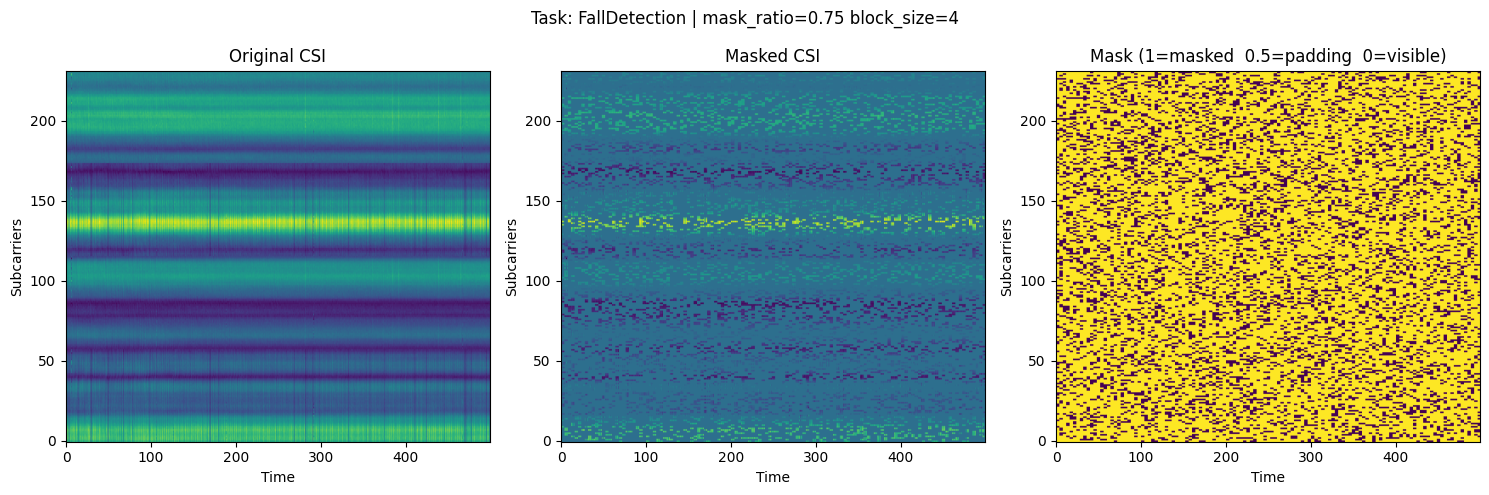

In [15]:
#!/usr/bin/env python3
import sys
import torch
import matplotlib.pyplot as plt

sys.path.append(".")  # run from project root

from load.pretrain_dataset import PretrainDataset
from torch.utils.data import DataLoader
from engine.masked_trainer import compute_padding_mask, create_padding_aware_mask
from load.dataloader import get_loaders

# --- Config ---
TASK     = "FallDetection"   # swap to any task you want to visualize
DATA_DIR = "data"
MASK_RATIO = 0.75
BLOCK_SIZE = 4

# --- Load one batch ---
ds = PretrainDataset(root=DATA_DIR, task=TASK, split="train_id",
                     task_dir=f"{DATA_DIR}/{TASK}")

loaders = get_loaders(root=DATA_DIR, task=TASK, batch_size=4)
loader = loaders["loaders"]["train"]
batch  = next(iter(loader))
x = batch[0] if isinstance(batch, (list, tuple)) else batch  # [B, T, F] or [B, 1, T, F]

# Add channel dim if needed
if x.dim() == 3:
    x = x.unsqueeze(1)

# --- Build masks ---
pad_mask    = compute_padding_mask(x)
signal_mask = create_padding_aware_mask(x, MASK_RATIO, BLOCK_SIZE)

# --- Plot first sample ---
x_3d      = x.squeeze(1)[0].cpu().numpy()
mask_np   = signal_mask[0].cpu().numpy()
pad_np    = pad_mask[0].cpu().numpy()
masked_np = x_3d * (1 - mask_np)

combined = mask_np.copy()
combined[pad_np] = 0.5  # padding=grey, masked=yellow, visible=purple

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(x_3d.T,      aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('Original CSI')
axes[1].imshow(masked_np.T, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title('Masked CSI')
axes[2].imshow(combined.T,  aspect='auto', origin='lower', cmap='viridis')
axes[2].set_title('Mask (1=masked  0.5=padding  0=visible)')

for ax in axes:
    ax.set_xlabel('Time')
    ax.set_ylabel('Subcarriers')

plt.suptitle(f"Task: {TASK} | mask_ratio={MASK_RATIO} block_size={BLOCK_SIZE}")
plt.tight_layout()
plt.savefig("FD_mask_visualization.png", dpi=120)
print("Saved mask_visualization.png")